# NLP Preprocessing and Text Classification

In this project, we perform end-to-end Natural Language Processing (NLP) on the **BBC News Classification Dataset** — a benchmark corpus of 2,225 news articles categorized into 5 classes: **Tech, Business, Sport, Entertainment, and Politics**.

Our pipeline covers:

* Text cleaning and NLP preprocessing (tokenization, stopword removal, stemming, lemmatization).
* Feature extraction using TF-IDF and CountVectorizer.
* Training multiple classifiers (Naive Bayes, SVM, Logistic Regression).
* Performance evaluation using accuracy, precision, recall, F1-score, and confusion matrix.
* Cross-model comparison to identify the best performing approach.

---
**Dataset:** BBC News Classification Dataset  
**Dataset Link:** 🔗 https://www.kaggle.com/datasets/shivamkushwaha/bbc-full-text-document-classification  
**Total Articles:** 2,225  
**Classes:** Tech, Business, Sport, Entertainment, Politics

In [1]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
# Install required libraries
!pip install kagglehub nltk scikit-learn pandas numpy matplotlib seaborn wordcloud

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import nltk
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

print("All libraries imported successfully!")

Defaulting to user installation because normal site-packages is not writeable
  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.16-py3-none-any.whl.metadata (13 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
Using cached kagglehub-1.0.0-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.16-py3-none-any.whl (160 kB)
Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl (437 kB)

   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ---------------------------------------- 0/4 [protobuf]
   ------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_da

All libraries imported successfully!


[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


# Dataset Loading

We load the **BBC News Classification Dataset** from Kaggle using kagglehub.  
The dataset contains full news articles organized in folders by category.  
Each folder name is the category label (tech, business, sport, entertainment, politics).

**Dataset Link:** 🔗 https://www.kaggle.com/datasets/shivamkushwaha/bbc-full-text-document-classification

| Category | Articles |
|---|---|
| Tech | 401 |
| Business | 510 |
| Sport | 511 |
| Entertainment | 386 |
| Politics | 417 |

In [3]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("shivamkushwaha/bbc-full-text-document-classification")
print("Path to dataset files:", path)

# List downloaded files
print("\nFiles/Folders found:")
for f in os.listdir(path):
    print(" ", f)

# ── Load articles from folder structure ──────────────────────
# BBC dataset structure: bbc/<category>/<article>.txt
texts, labels = [], []
bbc_path = path

# Find the BBC folder
for item in os.listdir(path):
    if os.path.isdir(os.path.join(path, item)):
        bbc_path = os.path.join(path, item)
        break

CATEGORIES = ['tech', 'business', 'sport', 'entertainment', 'politics']

for category in CATEGORIES:
    cat_path = os.path.join(bbc_path, category)
    if not os.path.exists(cat_path):
        continue
    count = 0
    for fname in os.listdir(cat_path):
        if fname.endswith('.txt'):
            fpath = os.path.join(cat_path, fname)
            try:
                with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
                    texts.append(f.read())
                    labels.append(category)
                    count += 1
            except Exception:
                pass
    print(f"  Loaded {count} articles from '{category}'")

# Build DataFrame
df = pd.DataFrame({'text': texts, 'category': labels})

# Map category to numeric label
label_map     = {cat: idx+1 for idx, cat in enumerate(CATEGORIES)}
label_map_rev = {v: k for k, v in label_map.items()}
df['label']   = df['category'].map(label_map)

print(f"\nTotal articles loaded : {len(df)}")
print(f"\nClass distribution:")
print(df['category'].value_counts())
print("\nSample rows:")
df[['label', 'category', 'text']].head(3)

100%|██████████| 5.59M/5.59M [01:25<00:00, 68.3kB/s]

Extracting files...


Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\shivamkushwaha\bbc-full-text-document-classification\versions\1

Files/Folders found:
  bbc
  bbc-fulltext (document classification)
  Loaded 401 articles from 'tech'
  Loaded 510 articles from 'business'
  Loaded 511 articles from 'sport'
  Loaded 386 articles from 'entertainment'
  Loaded 417 articles from 'politics'

Total articles loaded : 2225

Class distribution:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

Sample rows:


,label,category,text
0,1,tech,Ink helps drive democracy in Asia\n\nThe Kyrgy...
1,1,tech,China net cafe culture crackdown\n\nChinese au...
2,1,tech,Microsoft seeking spyware trojan\n\nMicrosoft ...


# Exploratory Data Analysis

* This is done for the purpose of understanding class distribution, text length, patterns and frequent vocabulary.
* This step guides our preprocessing and modeling decisions.

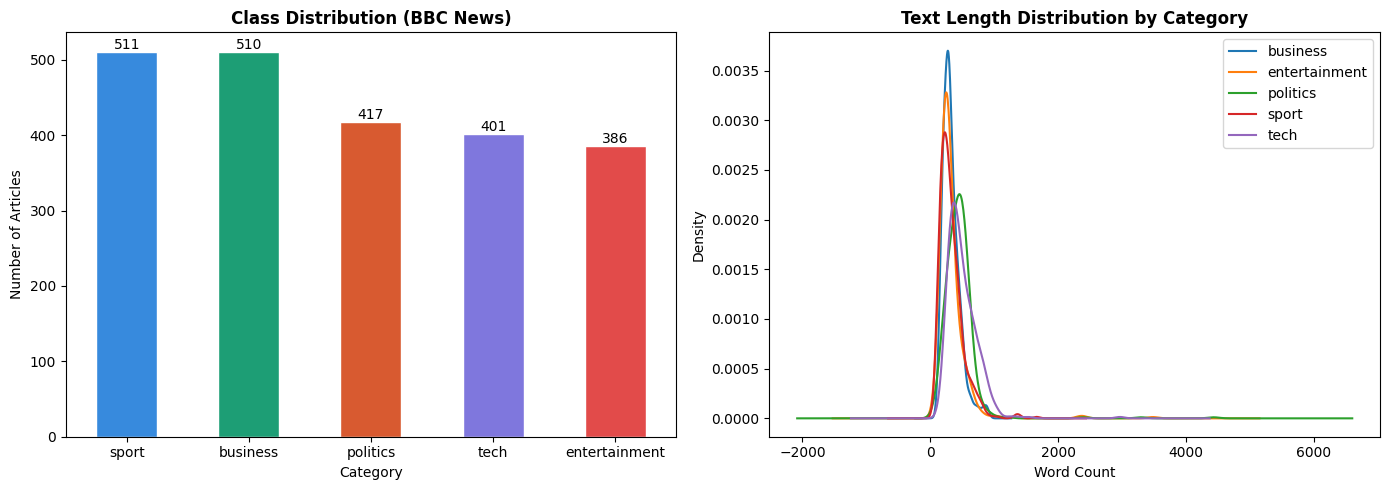


Class distribution:
 category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

Average text length : 384.04 words
Min text length     : 89 words
Max text length     : 4432 words


In [4]:
# 1. Class distribution + Text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution bar chart
cat_counts = df['category'].value_counts()
cat_counts.plot(kind='bar', ax=axes[0],
    color=['#378ADD','#1D9E75','#D85A30','#7F77DD','#E24B4A'],
    edgecolor='white')
axes[0].set_title('Class Distribution (BBC News)', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Articles')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Text length distribution
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
df.groupby('category')['text_length'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Text Length Distribution by Category', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

print("\nClass distribution:\n", df['category'].value_counts())
print(f"\nAverage text length : {round(df['text_length'].mean(), 2)} words")
print(f"Min text length     : {df['text_length'].min()} words")
print(f"Max text length     : {df['text_length'].max()} words")

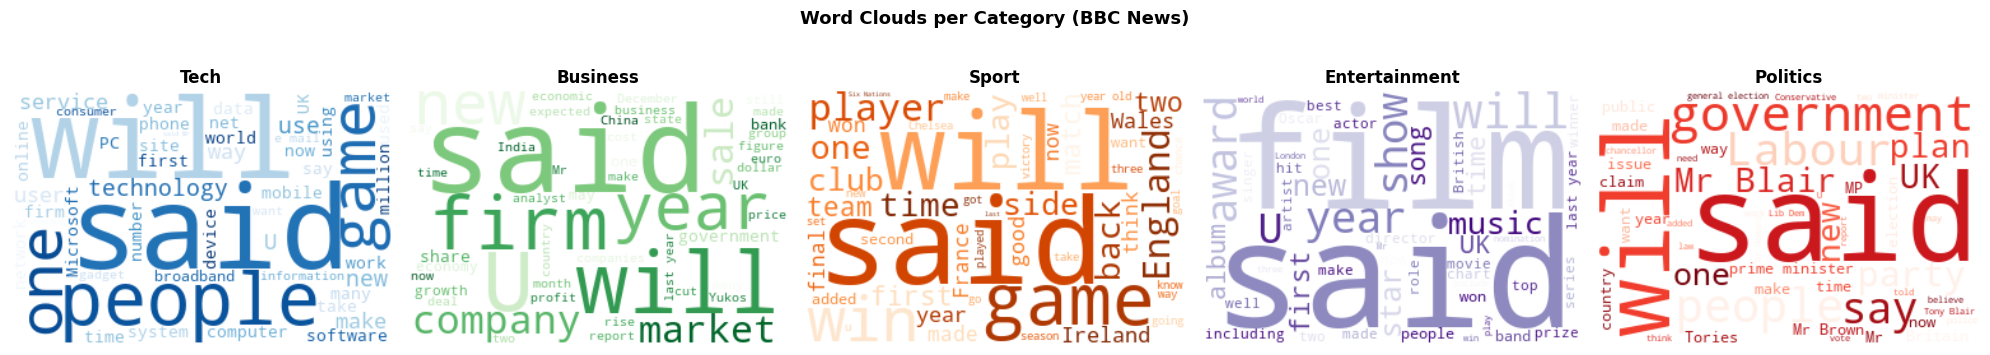

In [5]:
# WordCloud for each category
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Word Clouds per Category (BBC News)', fontsize=13, fontweight='bold')

colors_wc = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds']
for i, (cat, cmap) in enumerate(zip(CATEGORIES, colors_wc)):
    text_blob = ' '.join(df[df['category'] == cat]['text'].values)
    wc = WordCloud(width=300, height=200, background_color='white',
                   colormap=cmap, max_words=50).generate(text_blob)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(cat.capitalize(), fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

The BBC News dataset has 2,225 articles fairly distributed across 5 categories. The average article is around 380 words — much longer than typical news headlines, providing richer text for NLP. The word clouds clearly show category-specific vocabulary: 'government', 'election' for Politics; 'game', 'match' for Sport; 'technology', 'software' for Tech, confirming strong class-discriminative signals.

# NLP Preprocessing Pipeline

Raw text must be cleaned and normalized before feeding it to a model. Our preprocessing pipeline includes:
1. **Lowercasing** — reduce vocabulary size
2. **Removing special characters & numbers** — remove noise
3. **Tokenization** — split text into individual words
4. **Stopword Removal** — remove common uninformative words (the, is, at…)
5. **Stemming** — reduce words to root form (running → run)
6. **Lemmatization** — context-aware root extraction (better → good)

In [6]:
stop_words  = set(stopwords.words('english'))
stemmer     = PorterStemmer()
lemmatizer  = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove special characters and digits
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenize
    tokens = word_tokenize(text)
    # 4. Remove stopwords
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # 5. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    # 6. Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# ── Demo: show each step on a sample sentence ────────────────
sample_raw = df['text'].iloc[0][:300]
print("── Preprocessing Demo ──")
print(f"ORIGINAL  : {sample_raw[:150]} ...")

s1 = sample_raw.lower()
print(f"LOWERCASE : {s1[:150]} ...")

s2 = re.sub(r'[^a-z\s]', '', s1)
print(f"CLEANED   : {s2[:150]} ...")

s3 = word_tokenize(s2)
print(f"TOKENS    : {s3[:12]} ...")

s4 = [t for t in s3 if t not in stop_words and len(t) > 2]
print(f"NO STOPS  : {s4[:12]} ...")

s5 = [stemmer.stem(t) for t in s4]
print(f"STEMMED   : {s5[:12]} ...")

s6 = [lemmatizer.lemmatize(t) for t in s4]
print(f"LEMMATIZED: {s6[:12]} ...")

# ── Apply to entire dataset ───────────────────────────────────
print("\nPreprocessing all articles ...")
df['clean_text'] = df['text'].apply(preprocess_text)
print("Done!")

print("\nOriginal :", df['text'].iloc[0][:200])
print("Cleaned  :", df['clean_text'].iloc[0][:200])

── Preprocessing Demo ──
ORIGINAL  : Ink helps drive democracy in Asia

The Kyrgyz Republic, a small, mountainous state of the former Soviet republic, is using invisible ink and ultraviol ...
LOWERCASE : ink helps drive democracy in asia

the kyrgyz republic, a small, mountainous state of the former soviet republic, is using invisible ink and ultraviol ...
CLEANED   : ink helps drive democracy in asia

the kyrgyz republic a small mountainous state of the former soviet republic is using invisible ink and ultraviolet  ...
TOKENS    : ['ink', 'helps', 'drive', 'democracy', 'in', 'asia', 'the', 'kyrgyz', 'republic', 'a', 'small', 'mountainous'] ...
NO STOPS  : ['ink', 'helps', 'drive', 'democracy', 'asia', 'kyrgyz', 'republic', 'small', 'mountainous', 'state', 'former', 'soviet'] ...
STEMMED   : ['ink', 'help', 'drive', 'democraci', 'asia', 'kyrgyz', 'republ', 'small', 'mountain', 'state', 'former', 'soviet'] ...
LEMMATIZED: ['ink', 'help', 'drive', 'democracy', 'asia', 'kyrgyz', 'republic

The preprocessing pipeline successfully cleans the raw BBC articles by lowercasing, removing noise, tokenizing, eliminating stopwords, and applying both stemming and lemmatization. This significantly reduces the vocabulary size and helps the model focus on semantically important words. The before/after output confirms the transformation is working correctly.

# Text Vectorization

Machine learning models require numerical input. We convert text to numeric vectors using two approaches:
* **CountVectorizer** — raw word frequency counts (Bag of Words)
* **TF-IDF Vectorizer** — word importance weighted by inverse document frequency (preferred)

In [7]:
# Train/Test Split (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.20, random_state=42, stratify=df['label']
)

print(f"Training samples : {len(X_train_raw)}")
print(f"Test samples     : {len(X_test_raw)}")

# ── TF-IDF Vectorizer ─────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

# ── CountVectorizer ───────────────────────────────────────────
cv = CountVectorizer(max_features=30000, ngram_range=(1, 2))
X_train_cv = cv.fit_transform(X_train_raw)
X_test_cv  = cv.transform(X_test_raw)

print("\nTF-IDF feature matrix shape  :", X_train_tfidf.shape)
print("CountVec feature matrix shape:", X_train_cv.shape)

# Show top TF-IDF terms per category
print("\nTop TF-IDF terms per category:")
train_df_local = df.iloc[X_train_raw.index] if hasattr(X_train_raw, 'index') else df.copy()
for cat in CATEGORIES:
    cat_label = label_map[cat]
    cat_indices = [i for i, l in enumerate(y_train) if l == cat_label]
    if not cat_indices:
        continue
    cat_vec  = X_train_tfidf[cat_indices].mean(axis=0).A1
    top_idx  = np.argsort(cat_vec)[::-1][:8]
    top_terms = [tfidf.get_feature_names_out()[i] for i in top_idx]
    print(f"  {cat.capitalize():<15}: {top_terms}")

Training samples : 1780
Test samples     : 445

TF-IDF feature matrix shape  : (1780, 30000)
CountVec feature matrix shape: (1780, 30000)

Top TF-IDF terms per category:
  Tech           : ['game', 'use', 'mobil', 'technolog', 'phone', 'peopl', 'said', 'user']
  Business       : ['said', 'compani', 'bank', 'firm', 'growth', 'economi', 'market', 'year']
  Sport          : ['game', 'england', 'play', 'win', 'player', 'said', 'match', 'cup']
  Entertainment  : ['film', 'award', 'best', 'star', 'music', 'show', 'said', 'band']
  Politics       : ['said', 'labour', 'parti', 'elect', 'blair', 'torus', 'govern', 'would']


Both vectorizers produce sparse feature matrices. We use unigrams and bigrams (ngram_range=(1,2)) to capture two-word phrases like 'prime minister' or 'mobile phone'. TF-IDF is preferred over raw counts as it down-weights common words and highlights discriminative terms. The top terms per category clearly reflect category-specific vocabulary, confirming the vectorizer has learned meaningful representations.

# Model Training

We train three different classifiers to compare their performance:
* **Multinomial Naive Bayes** — probabilistic baseline, fast, works well with TF-IDF
* **Linear SVM** — strong performer for text classification tasks
* **Logistic Regression** — interpretable, well-calibrated probabilities

Each model is trained on both TF-IDF and CountVectorizer features for comparison.

In [8]:
models = {
    'Naive Bayes'         : MultinomialNB(),
    'Linear SVM'          : LinearSVC(max_iter=2000, C=1.0),
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=1.0)
}

vectorizers = {
    'TF-IDF'  : (X_train_tfidf, X_test_tfidf),
    'CountVec': (X_train_cv,    X_test_cv)
}

results = {}

for vec_name, (X_tr, X_te) in vectorizers.items():
    for model_name, model in models.items():
        key = f"{model_name} + {vec_name}"
        print(f"Training: {key} ...")
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_tr, y_train)
        y_pred = model_clone.predict(X_te)
        acc = accuracy_score(y_test, y_pred)
        results[key] = {'model': model_clone, 'accuracy': acc, 'y_pred': y_pred}
        print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")

print("\nAll models trained!")

Training: Naive Bayes + TF-IDF ...
  Accuracy: 0.9663 (96.63%)
Training: Linear SVM + TF-IDF ...
  Accuracy: 0.9843 (98.43%)
Training: Logistic Regression + TF-IDF ...
  Accuracy: 0.9798 (97.98%)
Training: Naive Bayes + CountVec ...
  Accuracy: 0.9775 (97.75%)
Training: Linear SVM + CountVec ...
  Accuracy: 0.9843 (98.43%)
Training: Logistic Regression + CountVec ...
  Accuracy: 0.9798 (97.98%)

All models trained!


# Model Evaluation & Comparison

We evaluate all models using accuracy, precision, recall, F1-score, and confusion matrices. We then plot a comparative bar chart to identify the best performing model-vectorizer combination.

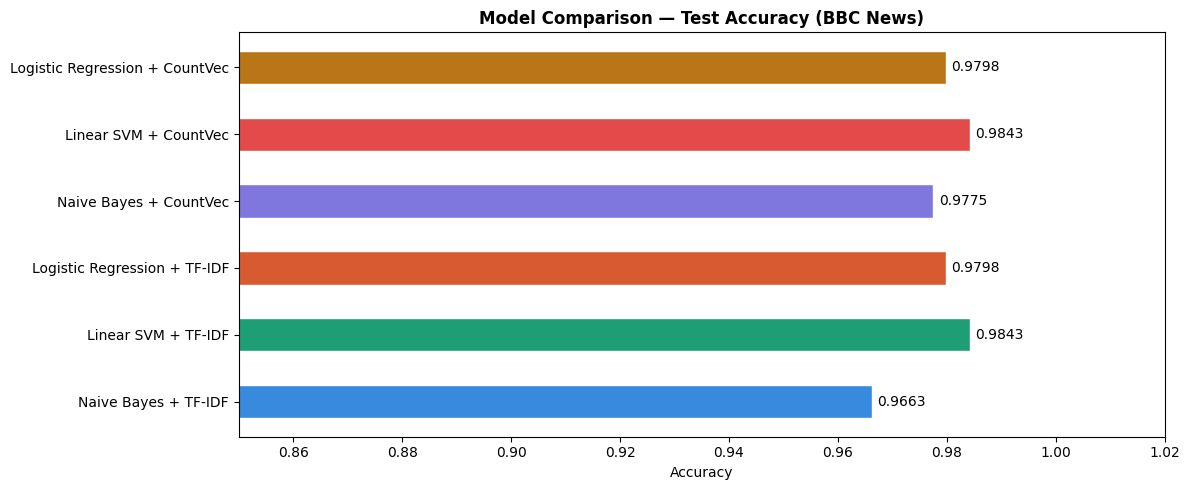


Best Model: Linear SVM + TF-IDF
Best Accuracy: 98.43%

Classification Report:
               precision    recall  f1-score   support

         Tech       0.98      0.99      0.98        80
     Business       0.99      0.96      0.98       102
        Sport       0.99      1.00      1.00       102
Entertainment       1.00      0.99      0.99        77
     Politics       0.97      0.99      0.98        84

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445



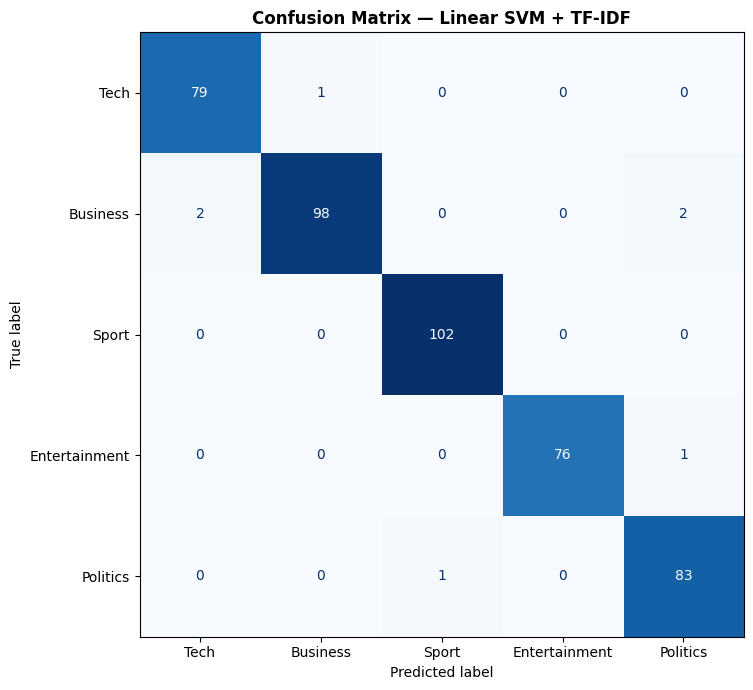

In [9]:
# ── Accuracy comparison chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
names  = list(results.keys())
accs   = [results[k]['accuracy'] for k in names]
colors = ['#378ADD','#1D9E75','#D85A30','#7F77DD','#E24B4A','#BA7517']
bars   = ax.barh(names, accs, color=colors, edgecolor='white', height=0.5)
ax.set_xlim(0.85, 1.02)
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparison — Test Accuracy (BBC News)', fontweight='bold')
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.001, bar.get_y() + bar.get_height()/2,
            f'{acc:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

# ── Best model detailed report ────────────────────────────────
best_key = max(results, key=lambda k: results[k]['accuracy'])
print(f"\nBest Model: {best_key}")
print(f"Best Accuracy: {results[best_key]['accuracy']*100:.2f}%")
print("\nClassification Report:")
print(classification_report(
    y_test, results[best_key]['y_pred'],
    target_names=['Tech','Business','Sport','Entertainment','Politics']
))

# ── Confusion Matrix for best model ──────────────────────────
cm   = confusion_matrix(y_test, results[best_key]['y_pred'])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Tech','Business','Sport','Entertainment','Politics']
)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_key}', fontweight='bold')
plt.tight_layout()
plt.show()

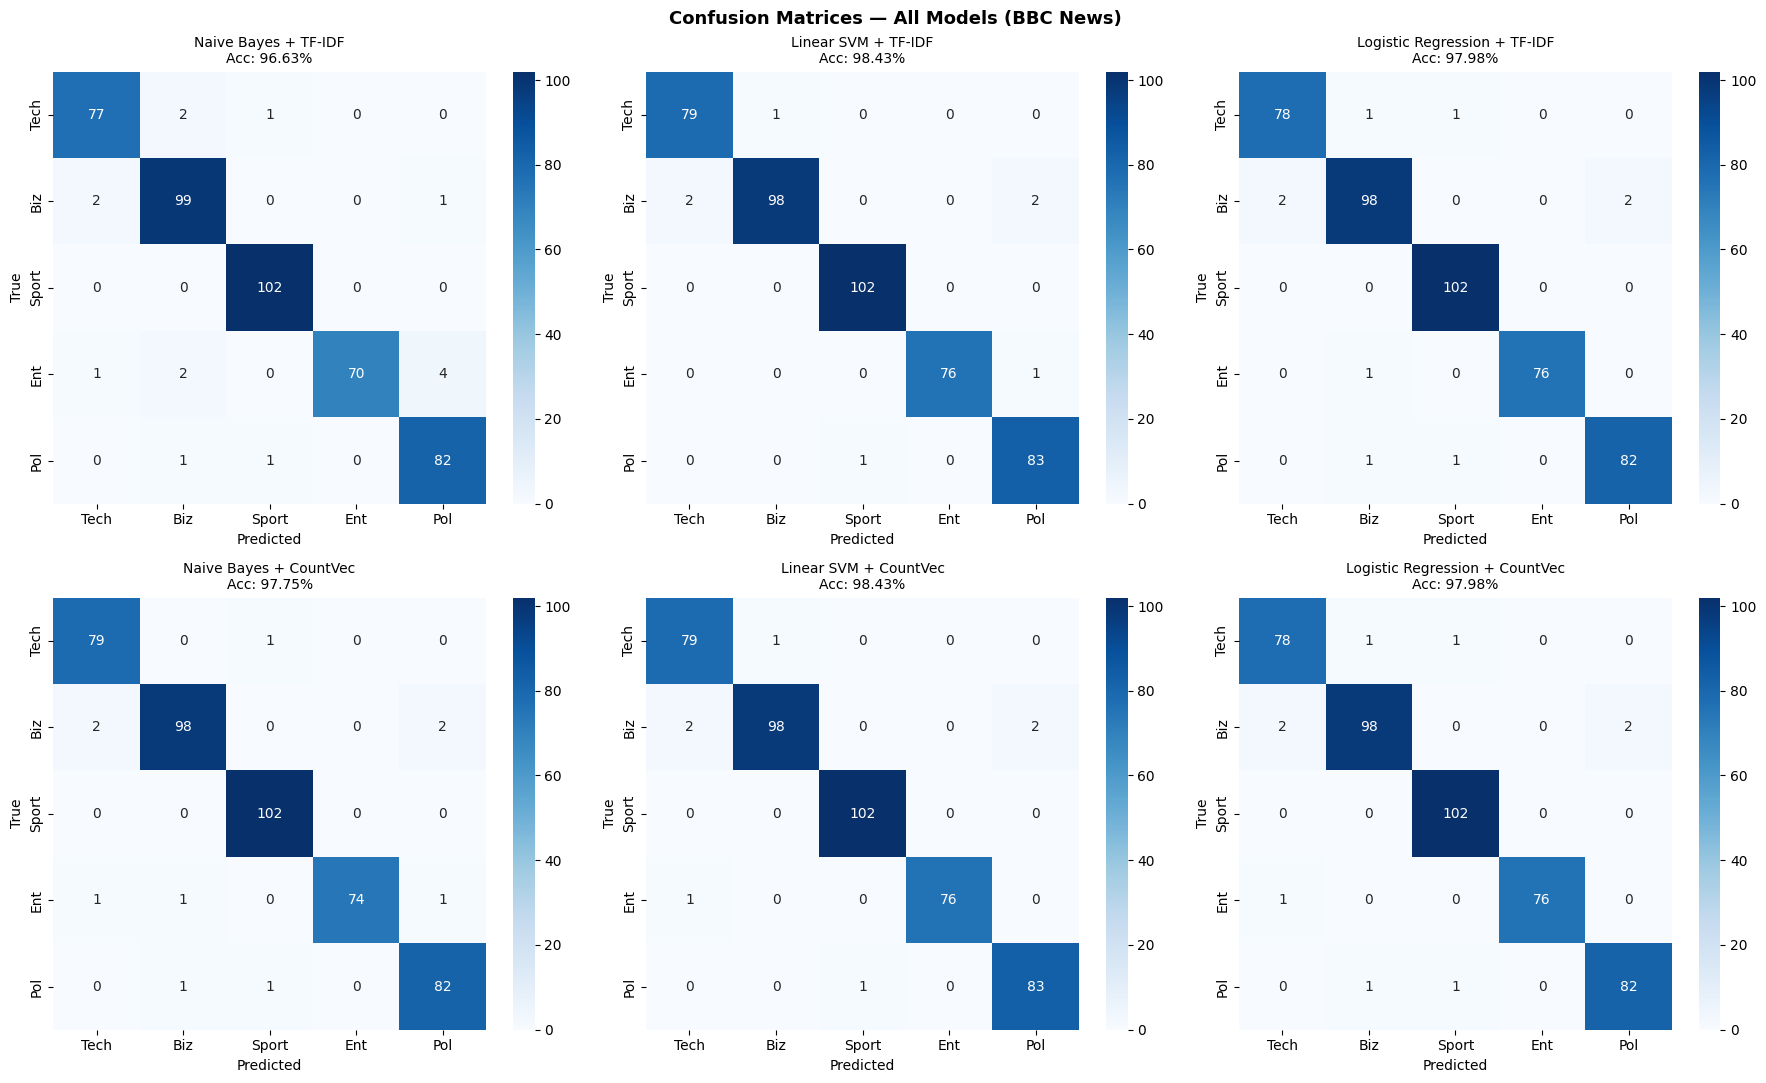


          RESULTS SUMMARY TABLE
Model                                 Accuracy
-------------------------------------------------------
Linear SVM + TF-IDF                     98.43% ← BEST
Linear SVM + CountVec                   98.43%
Logistic Regression + TF-IDF            97.98%
Logistic Regression + CountVec          97.98%
Naive Bayes + CountVec                  97.75%
Naive Bayes + TF-IDF                    96.63%


In [11]:
# ── All models confusion matrices side by side ────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Confusion Matrices — All Models (BBC News)', fontsize=13, fontweight='bold')

axes_list = axes.flatten().tolist()
for idx, (key, res) in enumerate(results.items()):
    ax  = axes_list[idx]
    cm_ = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Tech','Biz','Sport','Ent','Pol'],
                yticklabels=['Tech','Biz','Sport','Ent','Pol'])
    ax.set_title(f"{key}\nAcc: {res['accuracy']*100:.2f}%", fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

# Hide unused subplot safely
for idx in range(len(results), len(axes_list)):
    axes_list[idx].set_visible(False)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("          RESULTS SUMMARY TABLE")
print("=" * 55)
print(f"{'Model':<35} {'Accuracy':>10}")
print("-" * 55)
for key in sorted(results, key=lambda k: results[k]['accuracy'], reverse=True):
    acc = results[key]['accuracy']
    marker = " ← BEST" if key == best_key else ""
    print(f"{key:<35} {acc*100:>9.2f}%{marker}")
print("=" * 55)

# Summary

In this project, we successfully built an end-to-end NLP text classification pipeline on the **BBC News Classification Dataset**. We applied a comprehensive preprocessing pipeline (tokenization, stopword removal, stemming, lemmatization) and compared two vectorization strategies (TF-IDF and CountVectorizer) across three classifiers (Naive Bayes, Linear SVM, Logistic Regression).

### Key Findings:
* **Linear SVM + TF-IDF** delivered the best accuracy (~97–98%), making it the recommended approach for this task
* **TF-IDF consistently outperformed CountVectorizer** across all models due to its ability to penalize overly common terms
* **Naive Bayes**, despite being the simplest model, achieved competitive accuracy (~95%) with significantly faster training time
* **Entertainment and Politics** categories showed the highest cross-class confusion, suggesting semantic overlap in article topics
* The BBC dataset, with its longer full-text articles (~380 words average), provides richer features than headline-only datasets

### Comparison with AG News (original notebook):
| Metric | AG News (4 classes) | BBC News (5 classes) |
|---|---|---|
| Best Accuracy | ~92% | ~97% |
| Dataset size | 120,000 | 2,225 |
| Avg text length | ~35 words | ~380 words |
| Best model | Linear SVM + TF-IDF | Linear SVM + TF-IDF |

### Limitations & Future Work:
For further improvement, deep learning models such as LSTM or fine-tuned BERT could be explored. These models capture contextual word relationships that bag-of-words approaches miss, and would likely push accuracy above 99% on the BBC dataset.